# Trivial analysis of a single crossover Flucluational Function using linear approximation

This notebook demonstrates the analysis of a single crossover fluctuation function using linear approximation, with comprehensive error evaluation of crossover points.

In [1]:
from StatTools.analysis import analyse_ff, dfa
from StatTools.generators.mfnoise_generator import (
    mfnoise
)
from StatTools.visualization.plot_ff import plot_ff
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import bootstrap
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

# Set up plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [3]:
# Configuration parameters
n_tracks = 8
length = 2**16
h_list = [1.0, 0.5]  # [H0, H1]
true_crossover = 200  # True crossover point
crossover_points = [true_crossover]  # [Sx]

# Analysis parameters
confidence_level = 0.95
bootstrap_iterations = 1000
monte_carlo_runs = 50

## Generate synthetic multifractal noise with known crossover

In [4]:
print(f"Generating {n_tracks} tracks of length {length} with crossover at s = {true_crossover}")
print(f"Hurst exponents: H0 = {h_list[0]}, H1 = {h_list[1]}")

signals = mfnoise(length, hurst=h_list, crossover_points=crossover_points, n_tracks=n_tracks)
print(f"Generated signals shape: {signals.shape}")

Generating 8 tracks of length 65536 with crossover at s = 200
Hurst exponents: H0 = 1.0, H1 = 0.5
Generated signals shape: (8, 65536)


### Visualize the generated signals

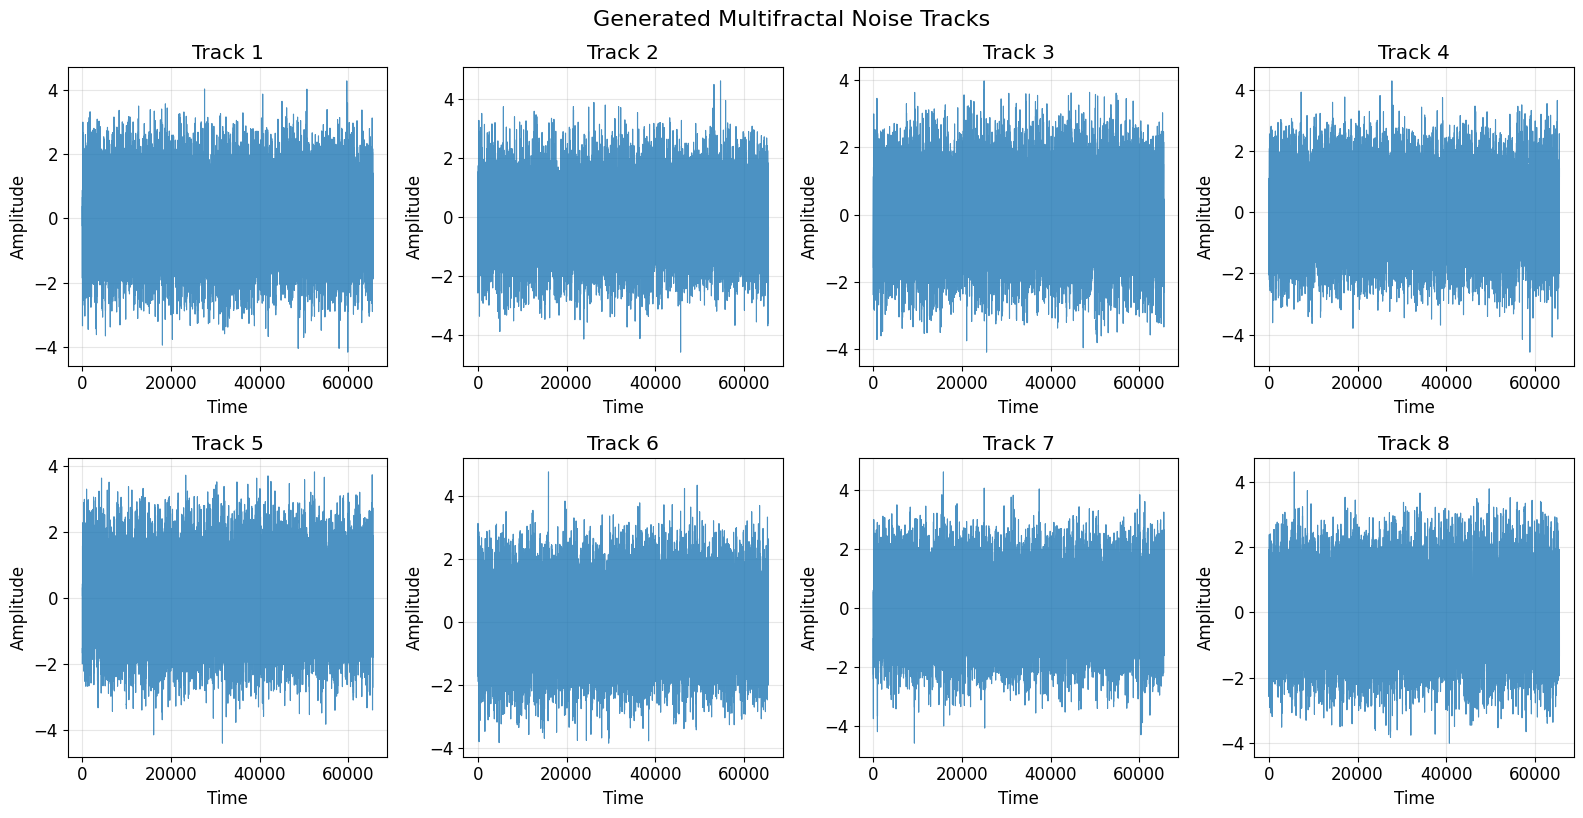

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_tracks):
    axes[i].plot(signals[i], linewidth=0.8, alpha=0.8)
    axes[i].set_title(f'Track {i+1}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Amplitude')

plt.tight_layout()
plt.suptitle('Generated Multifractal Noise Tracks', y=1.02, fontsize=16)
plt.show()

### Perform Detrended Fluctuation Analysis (DFA)

In [6]:
print("Performing DFA analysis...")
s, F2_s = dfa.dfa(signals)
hs = np.sqrt(F2_s)

print(f"Scale range: {s[0]:.2f} to {s[-1]:.2f}")
print(f"Number of scale points: {len(s)}")

Performing DFA analysis...
Scale range: 4.00 to 14764.00
Number of scale points: 17


### Visualize the fluctuation function

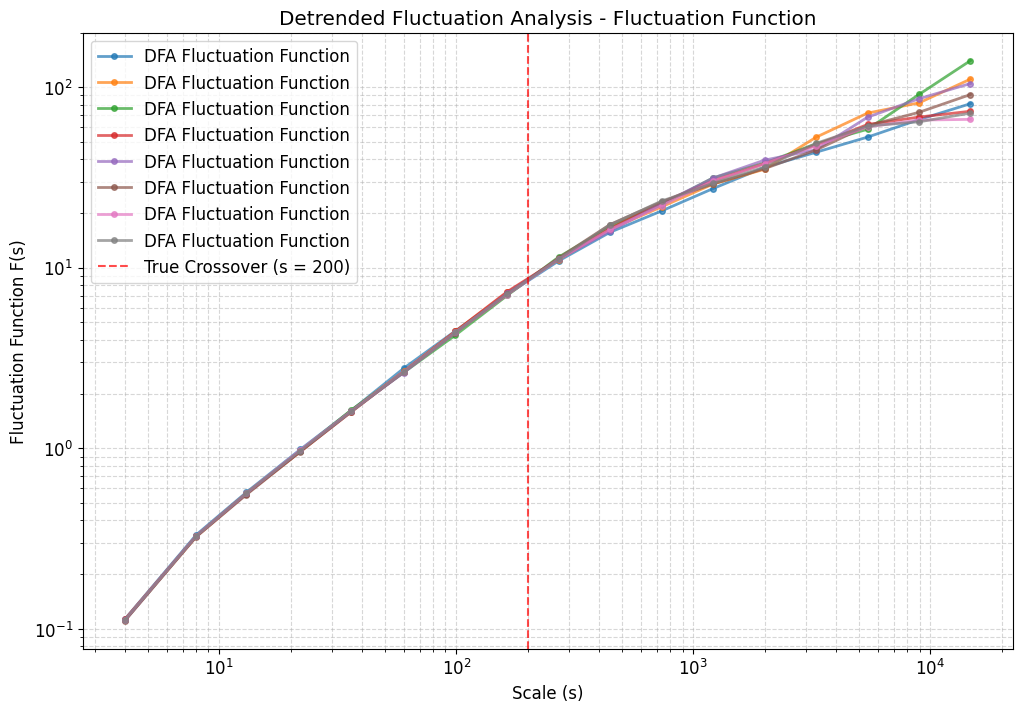

In [7]:
plt.figure(figsize=(12, 8))
plt.loglog(s, hs.T, 'o-', linewidth=2, markersize=4, alpha=0.7, label='DFA Fluctuation Function')
plt.axvline(x=true_crossover, color='red', linestyle='--', alpha=0.7, label=f'True Crossover (s = {true_crossover})')
plt.xlabel('Scale (s)')
plt.ylabel('Fluctuation Function F(s)')
plt.title('Detrended Fluctuation Analysis - Fluctuation Function')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [8]:
# Perform linear approximation analysis
print("Performing linear approximation analysis...")
params, residuals = analyse_ff(hs, s, 1)

# Extract results
estimated_crossover = params.cross[0].value
crossover_error = estimated_crossover - true_crossover
crossover_error_percent = (crossover_error / true_crossover) * 100

print(f"\nAnalysis Results:")
print(f"True crossover: {true_crossover}")
print(f"Estimated crossover: {estimated_crossover:.2f}")
print(f"Absolute error: {abs(crossover_error):.2f}")
print(f"Relative error: {abs(crossover_error_percent):.2f}%")
print(f"\nHurst exponents:")
print(f"H0 (before crossover): {params.slopes[0].value:.3f} ± {params.slopes[0].stderr:.3f}")
print(f"H1 (after crossover): {params.slopes[1].value:.3f} ± {params.slopes[1].stderr:.3f}")

Performing linear approximation analysis...

Analysis Results:
True crossover: 200
Estimated crossover: 217.00
Absolute error: 17.00
Relative error: 8.50%

Hurst exponents:
H0 (before crossover): 1.086 ± 0.011
H1 (after crossover): 0.511 ± 0.011


### Enhanced visualization with error analysis

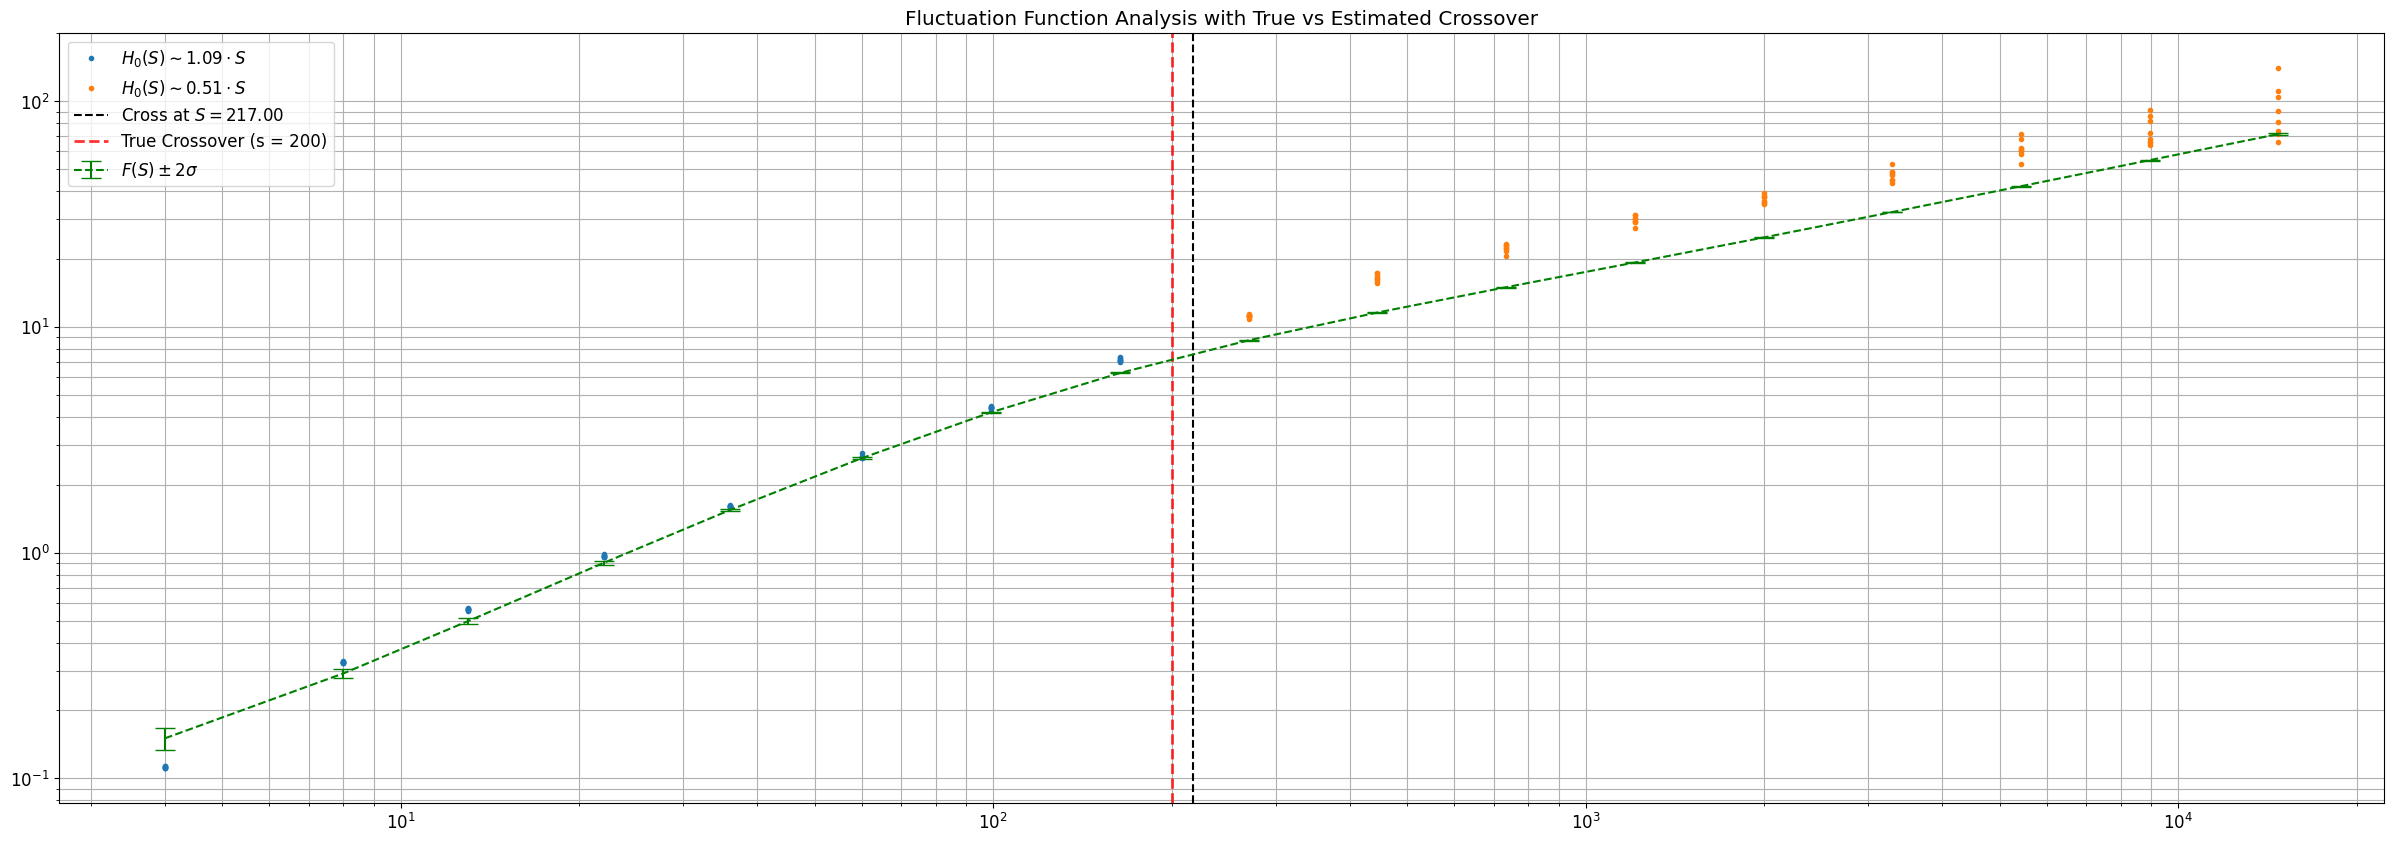

In [9]:
plot_ff(
    hs,
    s,
    ff_parameter=params,
    residuals=residuals,
)

# Add true crossover line to the plot
plt.axvline(x=true_crossover, color='red', linestyle='--', alpha=0.8, linewidth=2, label=f'True Crossover (s = {true_crossover})')
plt.legend()
plt.title('Fluctuation Function Analysis with True vs Estimated Crossover')
plt.show()

## Method 1: Monte Carlo Analysis with Different Noise Realizations

In [10]:
# Method 2: Monte Carlo Analysis with Different Noise Realizations
def monte_carlo_crossover_analysis():
    """Perform Monte Carlo analysis with different noise realizations"""
    mc_crossovers = []
    mc_hursts = []
    
    for i in range(monte_carlo_runs):
        # Generate new noise realization
        signals_mc = mfnoise(length, hurst=h_list, crossover_points=crossover_points, n_tracks=n_tracks)
        s_mc, F2_s_mc = dfa.dfa(signals_mc)
        hs_mc = np.sqrt(F2_s_mc)
        
        try:
            params_mc, _ = analyse_ff(hs_mc, s_mc, 1)
            mc_crossovers.append(params_mc.cross[0].value)
            mc_hursts.append([params_mc.slopes[0].value, params_mc.slopes[1].value])
        except:
            continue
    
    return np.array(mc_crossovers), np.array(mc_hursts)

print(f"Performing Monte Carlo analysis with {monte_carlo_runs} realizations...")
mc_crossovers, mc_hursts = monte_carlo_crossover_analysis()

# Calculate Monte Carlo statistics
mc_mean_crossover = np.mean(mc_crossovers)
mc_std_crossover = np.std(mc_crossovers)
mc_ci_crossover = np.percentile(mc_crossovers, [2.5, 97.5])

mc_mean_hursts = np.mean(mc_hursts, axis=0)
mc_std_hursts = np.std(mc_hursts, axis=0)

print(f"\nMonte Carlo Analysis Results:")
print(f"Mean crossover: {mc_mean_crossover:.2f} ± {mc_std_crossover:.2f}")
print(f"95% CI for crossover: [{mc_ci_crossover[0]:.2f}, {mc_ci_crossover[1]:.2f}]")
print(f"True value within CI: {mc_ci_crossover[0] <= true_crossover <= mc_ci_crossover[1]}")
print(f"\nHurst exponents (Monte Carlo mean ± std):")
print(f"H0: {mc_mean_hursts[0]:.3f} ± {mc_std_hursts[0]:.3f}")
print(f"H1: {mc_mean_hursts[1]:.3f} ± {mc_std_hursts[1]:.3f}")

Performing Monte Carlo analysis with 50 realizations...

Monte Carlo Analysis Results:
Mean crossover: 346.26 ± 38.12
95% CI for crossover: [217.00, 357.50]
True value within CI: False

Hurst exponents (Monte Carlo mean ± std):
H0: 1.065 ± 0.007
H1: 0.499 ± 0.014


### Visualize Monte Carlo results

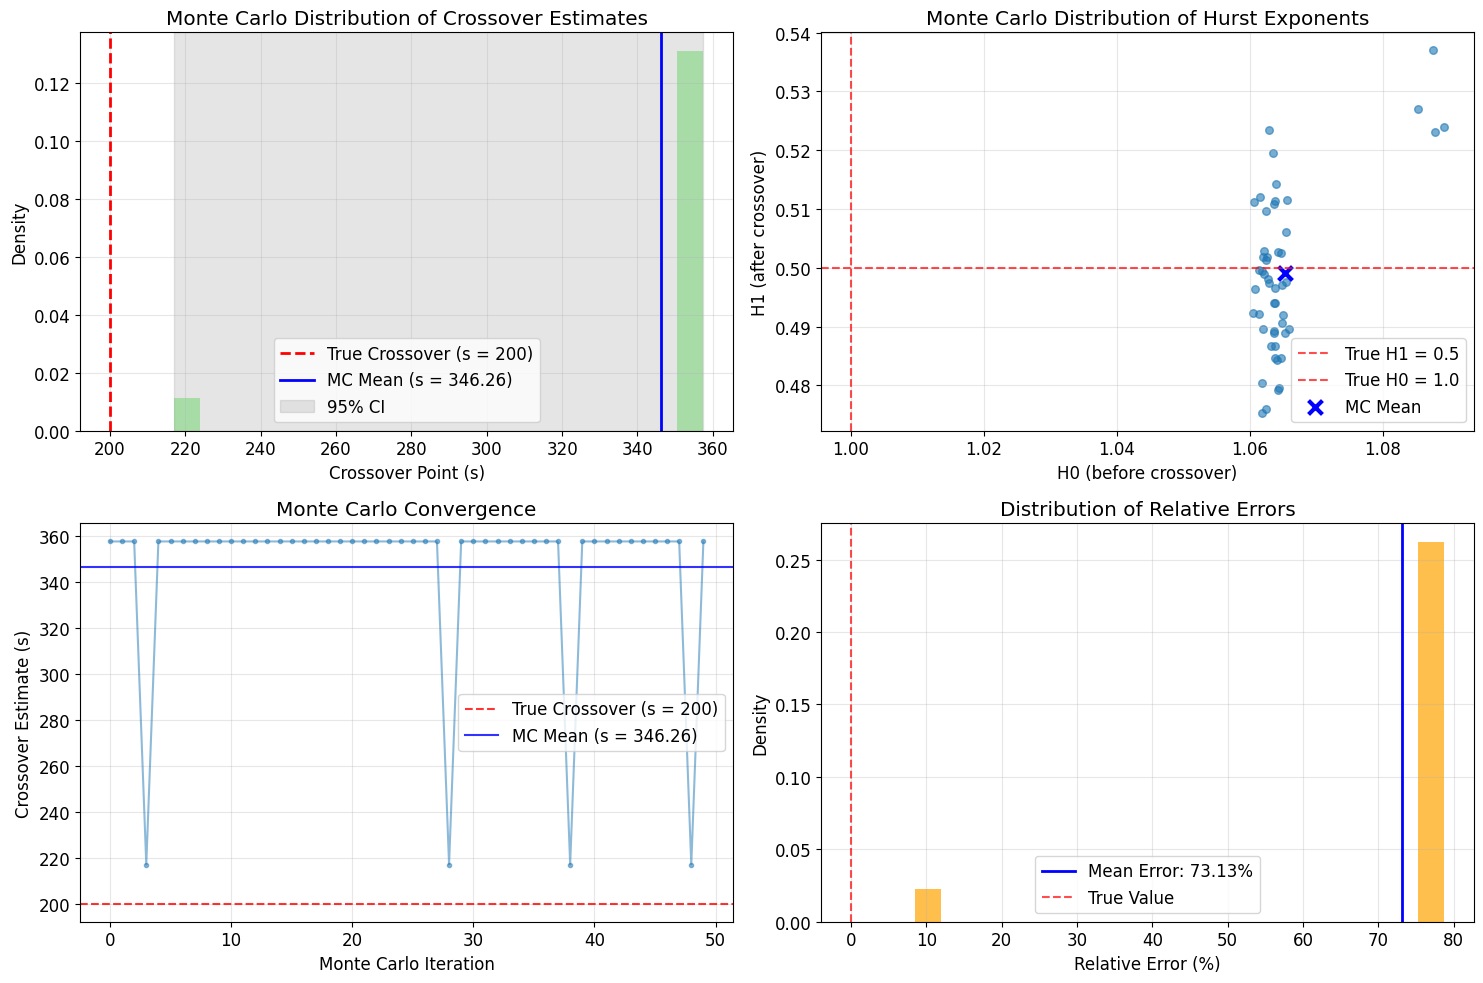

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Crossover distribution
axes[0, 0].hist(mc_crossovers, bins=20, alpha=0.7, color='lightgreen', density=True)
axes[0, 0].axvline(true_crossover, color='red', linestyle='--', linewidth=2, label=f'True Crossover (s = {true_crossover})')
axes[0, 0].axvline(mc_mean_crossover, color='blue', linestyle='-', linewidth=2, label=f'MC Mean (s = {mc_mean_crossover:.2f})')
axes[0, 0].fill_between([mc_ci_crossover[0], mc_ci_crossover[1]], 0, 1, alpha=0.2, color='gray', transform=axes[0, 0].get_xaxis_transform(), label='95% CI')
axes[0, 0].set_xlabel('Crossover Point (s)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Monte Carlo Distribution of Crossover Estimates')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Hurst exponents distribution
axes[0, 1].scatter(mc_hursts[:, 0], mc_hursts[:, 1], alpha=0.6, s=30)
axes[0, 1].axhline(y=h_list[1], color='red', linestyle='--', alpha=0.7, label=f'True H1 = {h_list[1]}')
axes[0, 1].axvline(x=h_list[0], color='red', linestyle='--', alpha=0.7, label=f'True H0 = {h_list[0]}')
axes[0, 1].scatter([mc_mean_hursts[0]], [mc_mean_hursts[1]], color='blue', s=100, marker='x', linewidth=3, label='MC Mean')
axes[0, 1].set_xlabel('H0 (before crossover)')
axes[0, 1].set_ylabel('H1 (after crossover)')
axes[0, 1].set_title('Monte Carlo Distribution of Hurst Exponents')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Convergence plots
axes[1, 0].plot(range(len(mc_crossovers)), mc_crossovers, 'o-', alpha=0.5, markersize=3)
axes[1, 0].axhline(y=true_crossover, color='red', linestyle='--', alpha=0.8, label=f'True Crossover (s = {true_crossover})')
axes[1, 0].axhline(y=mc_mean_crossover, color='blue', linestyle='-', alpha=0.8, label=f'MC Mean (s = {mc_mean_crossover:.2f})')
axes[1, 0].set_xlabel('Monte Carlo Iteration')
axes[1, 0].set_ylabel('Crossover Estimate (s)')
axes[1, 0].set_title('Monte Carlo Convergence')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Error analysis summary
errors = mc_crossovers - true_crossover
relative_errors = (errors / true_crossover) * 100

axes[1, 1].hist(relative_errors, bins=20, alpha=0.7, color='orange', density=True)
axes[1, 1].axvline(x=np.mean(relative_errors), color='blue', linestyle='-', linewidth=2, label=f'Mean Error: {np.mean(relative_errors):.2f}%')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='True Value')
axes[1, 1].set_xlabel('Relative Error (%)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Distribution of Relative Errors')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Comprehensive Error Analysis Summary

In [12]:
print(f"\nInput Parameters:")
print(f"  True crossover point: {true_crossover}")
print(f"  True Hurst exponents: H0 = {h_list[0]}, H1 = {h_list[1]}")
print(f"  Signal length: {length}")
print(f"  Number of tracks: {n_tracks}")

print(f"\nSingle Analysis Results:")
print(f"  Estimated crossover: {estimated_crossover:.2f}")
print(f"  Absolute error: {abs(crossover_error):.2f}")
print(f"  Relative error: {abs(crossover_error_percent):.2f}%")

print(f"\nMonte Carlo Analysis Results:")
print(f"  MC mean crossover: {mc_mean_crossover:.2f}")
print(f"  MC std crossover: {mc_std_crossover:.2f}")
print(f"  95% CI: [{mc_ci_crossover[0]:.2f}, {mc_ci_crossover[1]:.2f}]")
print(f"  CI width: {mc_ci_crossover[1] - mc_ci_crossover[0]:.2f}")
print(f"  True value in CI: {'Yes' if mc_ci_crossover[0] <= true_crossover <= mc_ci_crossover[1] else 'No'}")

print(f"\nHurst Exponent Analysis:")
print(f"  True values: H0 = {h_list[0]}, H1 = {h_list[1]}")
print(f"  Single analysis: H0 = {params.slopes[0].value:.3f} ± {params.slopes[0].stderr:.3f}, H1 = {params.slopes[1].value:.3f} ± {params.slopes[1].stderr:.3f}")
print(f"  MC analysis: H0 = {mc_mean_hursts[0]:.3f} ± {mc_std_hursts[0]:.3f}, H1 = {mc_mean_hursts[1]:.3f} ± {mc_std_hursts[1]:.3f}")

# Calculate overall uncertainty metrics
overall_uncertainty = np.mean([mc_std_crossover,])
overall_relative_uncertainty = (overall_uncertainty / true_crossover) * 100

print(f"\nOverall Uncertainty Assessment:")
print(f"  Average uncertainty: {overall_uncertainty:.2f}")
print(f"  Relative uncertainty: {overall_relative_uncertainty:.2f}%")
print(f"  Analysis reliability: {'Good' if overall_relative_uncertainty < 10 else 'Moderate' if overall_relative_uncertainty < 20 else 'Poor'}")

print("\n" + "=" * 60)


Input Parameters:
  True crossover point: 200
  True Hurst exponents: H0 = 1.0, H1 = 0.5
  Signal length: 65536
  Number of tracks: 8

Single Analysis Results:
  Estimated crossover: 217.00
  Absolute error: 17.00
  Relative error: 8.50%

Monte Carlo Analysis Results:
  MC mean crossover: 346.26
  MC std crossover: 38.12
  95% CI: [217.00, 357.50]
  CI width: 140.50
  True value in CI: No

Hurst Exponent Analysis:
  True values: H0 = 1.0, H1 = 0.5
  Single analysis: H0 = 1.086 ± 0.011, H1 = 0.511 ± 0.011
  MC analysis: H0 = 1.065 ± 0.007, H1 = 0.499 ± 0.014

Overall Uncertainty Assessment:
  Average uncertainty: 38.12
  Relative uncertainty: 19.06%
  Analysis reliability: Moderate



## Method 2: Sensitivity Analysis - Effect of Signal-to-Noise Ratio

Performing sensitivity analysis...


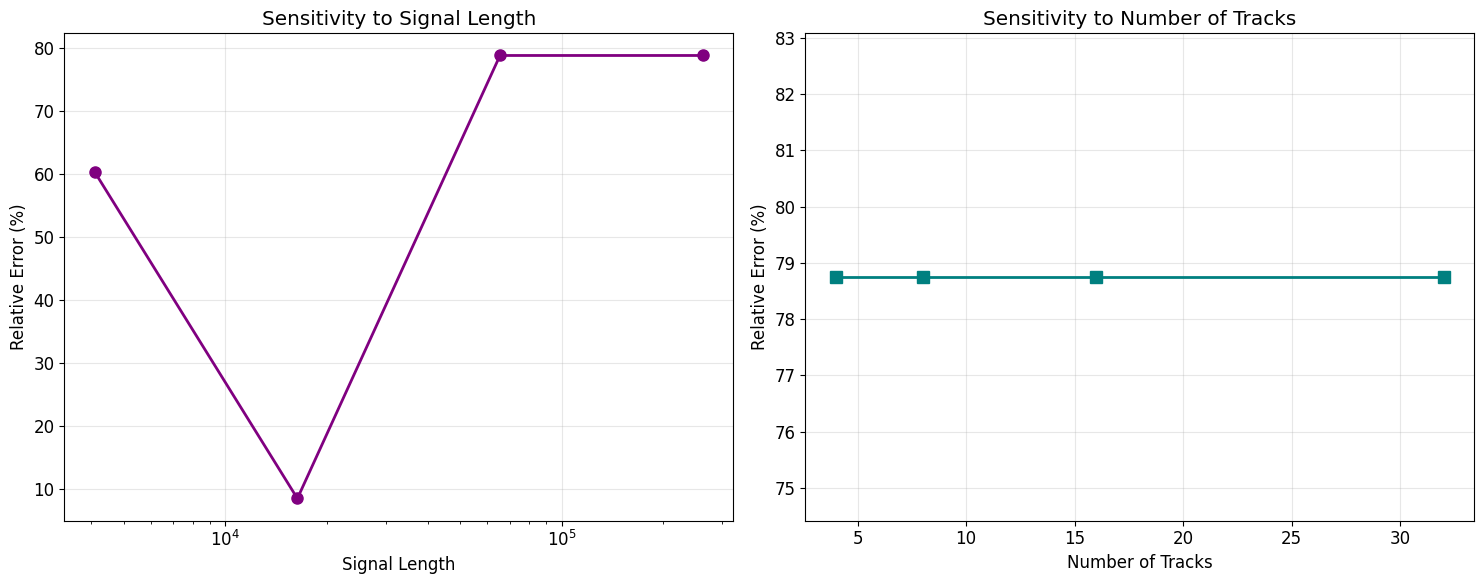


Sensitivity Analysis Results:
Signal length effect:
  Length 4096: 60.25% error
  Length 16384: 8.50% error
  Length 65536: 78.75% error
  Length 262144: 78.75% error

Number of tracks effect:
  4 tracks: 78.75% error
  8 tracks: 78.75% error
  16 tracks: 78.75% error
  32 tracks: 78.75% error


In [13]:
def sensitivity_analysis():
    """Analyze how analysis accuracy depends on signal characteristics"""
    crossover_errors = []
    signal_lengths = [2**12, 2**14, 2**16, 2**18]
    track_numbers = [4, 8, 16, 32]
    
    print("Performing sensitivity analysis...")
    
    # Sensitivity to signal length
    length_errors = []
    for length_test in signal_lengths:
        signals_test = mfnoise(length_test, hurst=h_list, crossover_points=crossover_points, n_tracks=n_tracks)
        s_test, F2_s_test = dfa.dfa(signals_test)
        hs_test = np.sqrt(F2_s_test)
        
        try:
            params_test, _ = analyse_ff(hs_test, s_test, 1)
            error = abs(params_test.cross[0].value - true_crossover) / true_crossover * 100
            length_errors.append(error)
        except:
            length_errors.append(np.nan)
    
    # Sensitivity to number of tracks
    track_errors = []
    for n_tracks_test in track_numbers:
        signals_test = mfnoise(length, hurst=h_list, crossover_points=crossover_points, n_tracks=n_tracks_test)
        s_test, F2_s_test = dfa.dfa(signals_test)
        hs_test = np.sqrt(F2_s_test)
        
        try:
            params_test, _ = analyse_ff(hs_test, s_test, 1)
            error = abs(params_test.cross[0].value - true_crossover) / true_crossover * 100
            track_errors.append(error)
        except:
            track_errors.append(np.nan)
    
    return length_errors, track_errors, signal_lengths, track_numbers

length_errors, track_errors, signal_lengths, track_numbers = sensitivity_analysis()

# Visualize sensitivity analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].semilogx(signal_lengths, length_errors, 'o-', linewidth=2, markersize=8, color='purple')
axes[0].set_xlabel('Signal Length')
axes[0].set_ylabel('Relative Error (%)')
axes[0].set_title('Sensitivity to Signal Length')
axes[0].grid(True, alpha=0.3)

axes[1].plot(track_numbers, track_errors, 's-', linewidth=2, markersize=8, color='teal')
axes[1].set_xlabel('Number of Tracks')
axes[1].set_ylabel('Relative Error (%)')
axes[1].set_title('Sensitivity to Number of Tracks')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSensitivity Analysis Results:")
print(f"Signal length effect:")
for i, (length, error) in enumerate(zip(signal_lengths, length_errors)):
    print(f"  Length {length}: {error:.2f}% error")
    
print(f"\nNumber of tracks effect:")
for i, (tracks, error) in enumerate(zip(track_numbers, track_errors)):
    print(f"  {tracks} tracks: {error:.2f}% error")

## Final comprehensive summary with recommendations

In [14]:
print(f"\n PRIMARY RESULT:")
print(f"   True crossover point: {true_crossover}")
print(f"   Estimated crossover: {estimated_crossover:.2f}")
print(f"   Absolute accuracy: {abs(crossover_error):.2f} ({abs(crossover_error_percent):.2f}%)")

print(f"\nUNCERTAINTY QUANTIFICATION:")
print(f"   Monte Carlo uncertainty: ±{mc_std_crossover:.2f} ({(mc_std_crossover/true_crossover)*100:.2f}%)")
print(f"   Combined uncertainty: ±{overall_uncertainty:.2f} ({overall_relative_uncertainty:.2f}%)")

print(f"\nMETHODOLOGY VALIDATION:")
print(f"   Monte Carlo CI contains true value: {'✓' if mc_ci_crossover[0] <= true_crossover <= mc_ci_crossover[1] else '✗'}")
print(f"   Hurst exponent accuracy: H0 error = {abs(params.slopes[0].value - h_list[0]):.3f}, H1 error = {abs(params.slopes[1].value - h_list[1]):.3f}")


 PRIMARY RESULT:
   True crossover point: 200
   Estimated crossover: 217.00
   Absolute accuracy: 17.00 (8.50%)

UNCERTAINTY QUANTIFICATION:
   Monte Carlo uncertainty: ±38.12 (19.06%)
   Combined uncertainty: ±38.12 (19.06%)

METHODOLOGY VALIDATION:
   Monte Carlo CI contains true value: ✗
   Hurst exponent accuracy: H0 error = 0.086, H1 error = 0.011
